# Setup

In [3]:
# Enter Optimizer Parameters
target = 228.6 # m
m_init = 475 # g

kp_low = 0.000001
kp_high = 0.001
kd_low = 0.00000001
kd_high = 0.00001
ki_low = 0.0000001
ki_high = 0.0001

# Initialize Optimizer
kp_values = []
kp_results = []

# Initialize Optimizer

In [4]:
# SITLsim_core.py
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import ast
import re
from sympy import symbols, sympify, lambdify

def run_simulation(csv_path, target_height=236.22, theta0=90, lrod_h=1.8288, base_wind=4.47, step=0.001,
                   run_until="Recovery Deployment", PID_TOGGLE="ON", ctrl_kp=0.0009999990, ctrl_kd=0.0000100000,
                   ctrl_ki=0.0000999999, ctrl_imu_error=0.03, ctrl_imu_delay=0.005, ctrl_baro_error=1.0,
                   ctrl_baro_delay=0.005, ctrl_sd_delay=0.005, ctrl_compute_delay=0.000, servo_speed = 375,
                   brakes_max_A = 0.0013524, servo_max_angle=37.55,
                   brake_angle_cmd_expr="brake_angle_cmd = 0.196 + 21942*A_needed + 4.07E+06*A_needed**2",
                   brake_angle_to_area_expr="brake_angle_to_area = -5.19E-06 + 4.36E-05*angle + -1.96E-07*angle**2",
                   brake_area_to_cd_expr="brake_area_to_cd = 1178*A_brakes + 11218*A_brakes**2"):

    ########### INPUTS #################
    # theta0 == Launch angle (deg)
    # lrod_h == Launch rod height (m)
    # base_wind == 4.47 # At y=10m (m/s)
    wind_shear_exponent = 1/7
    elevation = 183 # m
    ####### Control System Inputs #######
    h_target = target_height # m

    # Avionics inputs
    #ctrl_imu_error = 0.03 # m/s^2 (IMU error)
    #ctrl_imu_delay = 0.005 # s (IMU response time)
    #ctrl_baro_error = 1.0 # m (Barometer error)
    #ctrl_baro_delay = 0.005 # s (Barometer response time)
    #ctrl_sd_delay = 0.005 # s (SD card write time)
    #ctrl_compute_delay = 0.000 # s (CPU compute time)

    # Control constants inputs
    #ctrl_kp = 0.0009999990 # Kp
    #ctrl_kd = 0.0000100000 # Kd
    #ctrl_ki = 0.0000999999 # Ki

    # Physical systems inputs
    #servo_speed = 375 # deg/s (Speed servo rotates at)
    #servo_max_angle = 37.55 # deg (Maximum angle servo can rotate to in airbrake system)
    #brakes_max_A = 0.0013524 # m^2 (Maximum total area of brakes)

    # Parse and create airbrake behavior functions (by Gemini Flash 3.5)
    def generate_clipped_functions(input_strings, clip_bounds, execution_globals):
        for raw_input in input_strings:
            # 1. Clean the line and extract the function name and math text
            cleaned = raw_input.strip().rstrip(',')
            if '=' not in cleaned:
                continue

            lhs, rhs = cleaned.split('=', 1)
            func_name = lhs.strip()

            try:
                math_text = ast.literal_eval(rhs.strip())
            except (ValueError, SyntaxError):
                math_text = rhs.strip()

            # 2. Find the variable name inside the expression
            expr = sympify(math_text)
            free_symbols = [str(sym) for sym in expr.free_symbols]
            if not free_symbols:
                raise ValueError(f"No variable found in expression: {math_text}")
            var_name = free_symbols[0]

            # 3. Match function name to its corresponding clip ceiling limit
            max_bound = clip_bounds.get(func_name, "None")

            # 4. Construct Python function definition string
            func_template = f"""
def {func_name}({var_name}):
    return np.clip({math_text}, 0, {max_bound})
    """
            # 5. Execute using execution_globals so it links to script constants
            exec(func_template, execution_globals)
            # print(f"Generated function: {func_name}({var_name}) -> clipped at {max_bound}")

    # --- TEXT INPUTS --- (by Gemini Flash 3.5)
    inputs = [brake_angle_cmd_expr, brake_angle_to_area_expr, brake_area_to_cd_expr]

    bounds_mapping = {
        'brake_angle_cmd': 'servo_max_angle',
        'brake_angle_to_area': 'brakes_max_A',
        'brake_area_to_cd': None
    }

    # --- GENERATE THE FUNCTIONS --- (by Gemini Flash 3.5)
    globals().update({'servo_max_angle': servo_max_angle, 'brakes_max_A': brakes_max_A})
    generate_clipped_functions(inputs, bounds_mapping, globals())
    # Generates brake_angle_cmd(A_needed)
    # Generates brake_angle_to_area(angle)
    # Generates brake_area_to_cd(A_brakes)

    #def brake_angle_cmd(A_needed): # (Get servo angle based off brake area needed)
        #return np.clip(0.196 + 21942*A_needed + 4.07E+06*A_needed**2, 0, servo_max_angle)
    #def brake_angle_to_area(angle): # (Get brake area based off servo angle)
        #return np.clip(-5.19E-06 + 4.36E-05*angle + -1.96E-07*angle**2, 0, brakes_max_A)

    ########## Initialize other variables ##########
    ctrl_delay = ctrl_imu_delay + ctrl_baro_delay + ctrl_sd_delay + ctrl_compute_delay # Find total controller delay
    ctrl_delay = np.round(ctrl_delay, decimals=3) # Round controller delay
    next_imu_run = ctrl_imu_delay # Schedules IMU to respond with delay just after launch
    next_ctrl_run = ctrl_delay # Schedules controller to respond with delay just after launch
    d_brake_angle = servo_speed # Servo speed (deg/s)
    ctrl_ay = 0
    smoothed_ay = 0
    ay_history = []
    ctrl_ax = 0
    ctrl_a = 0
    ctrl_v = 0
    ctrl_y = 0
    ctrl_theta = 0
    ctrl_predict = 0
    ctrl_predict_k = 0
    ctrl_a_drag = 0
    A_brakes = 0
    ctrl_brake_angle_cmd = 0
    ctrl_brake_angle_pos = 0
    u = 0
    du = 0
    u_cmd = 0
    last_u_cmd = 0
    phys_angle = 0
    error_last = 0
    error = 0
    error_history = []
    dE = 0
    dE_last = 0
    error_integral = 0
    def noise(init_value, error):
        sign = random.getrandbits(1) * 2 - 1
        result = init_value + error*sign
        return result


    # SIMULATION CONTROL
    # run_until == "Apogee", "Recovery Deployment", "Landing", and {sec} Options | WARNING: DESCENT SIM NOT ACCURATE
    # step == Simulation resolution
    return_step = 0.01  # Returned data resolution

    # GENERAL CONSTANTS
    mass_earth = 5.97216786735e24 # kg
    radius_earth = 6378137 # m
    G_newt = 6.67430e-11 # Newton's gravitational constant
    g = 9.81 # m/s^2
    e = np.e
    rho_0 = 1.225  # kg/m³ (air density at sea level)
    L = 0.0065  # K/m (temperature lapse rate)
    T_0 = 288.15  # K (temperature at sea level)
    M = 0.0289644  # kg/mol (molar mass of Earth's air)
    R = 8.31447  # J/mol·K (universal gas constant)

        ######### IMPORT OPENROCKET DATA (ORI=OPENROCKET IMPORT) #############
    # Detect if running in Google Colab (by Gemini Flash 3.5)
    if 'google.colab' in sys.modules:
        # Path inside Colab's file system
        csv_path = "/content/ORI.csv"
    else:
        # Local path for VS Code
        csv_path = "~/Downloads/ORI.csv"

    # Pathlib validates whichever path was chosen (by Gemini Flash 3.5)
    csv_file = Path(csv_path).expanduser()
    if not csv_file.is_file():
        raise FileNotFoundError(f"CSV file not found: {csv_file}")

    ori = pd.read_csv(csv_file)

    # Find apogee
    if 'Vertical velocity (m/s)' not in ori.columns:
        raise ValueError("The selected CSV is missing the required 'Vertical velocity (m/s)' column.")

    apogee_mask = ori['Vertical velocity (m/s)'] < 0
    if apogee_mask.any():
        apogee_index = apogee_mask.idxmax()
    else:
        apogee_index = len(ori) - 1

    # Find parachute Cd (WARNING: innacurate descent model, use with caution)
    avg_pre_dep_cd = np.mean(ori['Drag coefficient (​)'].loc[:apogee_index])
    chute_mask = ori['Drag coefficient (​)'] > 5 * avg_pre_dep_cd
    if chute_mask.any():
        chute_dep_index = chute_mask.idxmax()
        recovery_cd = np.mean(ori['Drag coefficient (​)'].loc[chute_dep_index:])
        chute_dep_t = ori.iat[max(chute_dep_index - 1, 0), 0]
    else:
        chute_dep_index = len(ori) - 1
        recovery_cd = avg_pre_dep_cd
        chute_dep_t = ori.iat[max(len(ori) - 1, 0), 0]

    # Delete data after apogee (useless)
    ori = ori.loc[:apogee_index]

    # Convert aoa from deg to rad
    ori['Angle of attack (°)'] = ori['Angle of attack (°)'] * np.pi/180

    # Find A_rocket
    A_rocket = ori.at[1, 'Reference area (cm²)'] / 10000 # cm^2 to m^2

    # Find t_burn
    thrust_series = ori['Thrust (N)']
    burn_mask = thrust_series.iloc[5:] == 0
    if burn_mask.any():
        t_burn_index = burn_mask.idxmax()
        t_burn = ori.iat[t_burn_index, 0]
    else:
        t_burn = ori.iat[max(len(ori) - 1, 0), 0]

    # Mass interpolation
    mass_data = interp1d(ori['# Time (s)'], ori['Mass (g)'] / 1000, kind="linear", fill_value="extrapolate")
    interpolated_times = np.arange(ori['# Time (s)'].min(), ori['# Time (s)'].max(), step)  # Sim time step
    interpolated_mass = mass_data(interpolated_times)
    masses = pd.DataFrame({"t": interpolated_times, "m": interpolated_mass})

    # Thrust interpolation
    F_thrust = interp1d(ori['# Time (s)'], ori['Thrust (N)'], kind="linear", fill_value="extrapolate")
    interpolated_thrust = F_thrust(interpolated_times)
    thrusts = pd.DataFrame({"t": interpolated_times, "N": interpolated_thrust})

    # Get Cd (could do cd based on reynolds number later (Re is based on vel))
    Cd_avg = np.mean(ori['Drag coefficient (\u200b)'])

    # Axial Cd interpolation
    raw_Cd_a_data = interp1d(ori['Angle of attack (°)'], ori['Axial drag coefficient (\u200b)'], kind="linear", fill_value="extrapolate")
    interpolated_aoas = np.arange(ori['Angle of attack (°)'].min(), ori['Angle of attack (°)'].max(), 0.001)
    interpolated_Cd_a = raw_Cd_a_data(interpolated_aoas)
    Cd_a_data = pd.DataFrame({"aoa": interpolated_aoas, "Cd_a": interpolated_Cd_a})

    # Normal Force Coefficient (Cn) interpolation
    raw_Cn_data = interp1d(ori['Angle of attack (°)'], ori['Normal force coefficient (​)'], kind="linear", fill_value="extrapolate")
    interpolated_Cn = raw_Cn_data(interpolated_aoas)
    Cn_data = pd.DataFrame({"aoa": interpolated_aoas, "Cn": interpolated_Cn})

    # Cg interpolation
    raw_Cg_data = interp1d(ori['# Time (s)'], ori['CG location (cm)'] / 100, kind="linear", fill_value="extrapolate")
    interpolated_Cg = raw_Cg_data(interpolated_times)
    Cg_data = pd.DataFrame({"t": interpolated_times, "Cg": interpolated_Cg})

    # Cp interpolation
    raw_Cp_data = interp1d(ori['Angle of attack (°)'], ori['CP location (cm)'] / 100, kind="linear", fill_value="extrapolate")
    interpolated_Cp = raw_Cp_data(interpolated_aoas)
    Cp_data = pd.DataFrame({"aoa": interpolated_aoas, "Cp": interpolated_Cp})

    # I_z interpolation
    raw_Iz_data = interp1d(ori['# Time (s)'], ori['Rotational moment of inertia (kg·m²)'], kind="linear", fill_value="extrapolate")
    interpolated_Iz = raw_Iz_data(interpolated_times)
    Iz_data = pd.DataFrame({"t": interpolated_times, "Iz": interpolated_Iz})

    # Theta Damping Coefficient interpolation
    raw_pdc_data = interp1d(ori['Angle of attack (°)'], ori['Pitch damping coefficient (​)'], kind="linear", fill_value="extrapolate")
    interpolated_pdc = raw_pdc_data(interpolated_aoas)
    pdc_data = pd.DataFrame({"aoa": interpolated_aoas, "pdc": interpolated_pdc})

    ori_max_aoa = np.max(interpolated_aoas)
    ori_max_t = np.max(ori['# Time (s)'])
    ori = pd.read_csv(csv_file)
    ################################################################################
    # DEFINE FUNCTIONS

    # Thrust function
    def thrust(t):
        if t <= t_burn:
            return np.interp(t, thrusts["t"], thrusts["N"])
        else:
            return 0

    # Adjust Drag Force with Angle using Cd_data
    def rho(y):
        return rho_0 * (1 - L * (y+elevation) / T_0) ** 4.25588

    def Cd(v): # (Later, get cd vs aoa from OpenRocket)
        return Cd_avg

    def drag(v, y, aoa, A_brakes):
        Cd_base = Cd(aoa)
        Cd_brakes = brake_area_to_cd(A_brakes)
        Cd_total = Cd_base + Cd_brakes
        A = A_rocket + A_brakes
        air_density = rho(y)
        drag_force = 0.5 * Cd_total * air_density * v**2 * A
        return drag_force

    # Mass as a function of time
    def mass(t):
        if t <= t_burn:
            return np.interp(t, masses["t"], masses["m"])
        else:
            return np.interp(t_burn, masses["t"], masses["m"])

    # Wind speed function
    def wind_speed(y):
        if y > lrod_h:
            return base_wind * ((y / 10)**wind_shear_exponent)
        else:
            return 0

    # Weathercocking angle calculation
    def weathercocking(v, y):
        if y > lrod_h:
            W = wind_speed(y)
            if W > 0:
                wind_effect = np.arctan(v / W)
                return theta0 - (np.pi / 2) + wind_effect
            else:
                return theta0
        else:
            return theta0

    # Flight path angle calculation
    def gamma_calc(vy, vx):
        if np.hypot(vx, vy) <= 1e-9:
            gamma = theta
        else:
            gamma = np.arctan2(vy,vx)
        return gamma

    # Normal Force Coefficient calculation
    def Cn(aoa):
        aoa_clamped = np.clip(aoa, Cn_data["aoa"].min(), Cn_data["aoa"].max())
        return np.interp(aoa_clamped, Cn_data["aoa"], Cn_data["Cn"])

    # Normal Force calculation
    def Fn(v, y, aoa):
        Cn_value = Cn(aoa)
        air_density = rho(y)
        normal_force = 0.5 * Cn_value * air_density * v**2 * A_rocket
        return normal_force

    # Axial Drag Coefficient calculation
    def cda(aoa, A_brakes):
        if t <= chute_dep_t:
            aoa_clamped = np.clip(aoa, Cd_a_data["aoa"].min(), Cd_a_data["Cd_a"].max())
            Cd_brakes = brake_area_to_cd(A_brakes)
            return np.interp(aoa_clamped, Cd_a_data["aoa"], Cd_a_data["Cd_a"]) + Cd_brakes
        else:
            return recovery_cd

    # Cg calculation
    def locate_Cg(t):
        if t <= ori_max_t:
            return np.interp(t, Cg_data["t"], Cg_data["Cg"])
        else:
            return np.interp(ori_max_t, Cg_data["t"], Cg_data["Cg"])

    # Cp calculation
    def locate_Cp(aoa, brake_angle=0):
        if t <= chute_dep_t:
            if brake_angle == 0:
                aoa_clamped = np.clip(aoa, Cp_data["aoa"].min(), Cp_data["Cp"].max())
                return np.interp(aoa_clamped, Cp_data["aoa"], Cp_data["Cp"])
            else:
                return 0.442 # temporary: do CFD to find Cp dif and then apply that dif based on brake area function
        else:
            return Cp_data["Cp"].min()

    # Iz calculation
    def Iz(t):
        if t <= ori_max_t:
            return np.interp(t, Iz_data["t"], Iz_data["Iz"])
        else:
            return np.interp(ori_max_t, Iz_data["t"], Iz_data["Iz"])

    # PDC calculation
    def pdc(aoa):
        if aoa <= ori_max_aoa:
            return np.interp(aoa, pdc_data["aoa"], pdc_data["pdc"])
        else:
            return np.interp(ori_max_aoa, pdc_data["aoa"], pdc_data["pdc"])

    # Simulation end point
    def run_condition():
        if run_until == "Apogee":
            return vy >= 0
        elif run_until == "Landing":
            return y >= 0
        elif isinstance(run_until, (int, float)):
            return t <= run_until
        else: # Defaults to until recovery deployment
            return t <= chute_dep_t

    ############## RUN COMPUTATION #####################
    global t, v, y, x, results, apogee  # Ensure function modifies global variables
    results = []
    results.clear()
    y = 0  # Reference altitude for windspeed (m)
    x = 0  # Horizontal position (m)
    vx = 0  # Initial x-velocity (m/s)
    vy = 0  # Initial y-velocity (m/s)
    v = 0 # Initial velocity (m/s)
    flight_time = 0
    vx_apparent = 0 # Initial x-velocity relative to air (m/s)
    vy_apparent = 0 # Initial y-velocity relative to air (m/s)
    v_apparent = 0 # Initial velocity relative to air (m/s)
    ax = 0 # Initial x-acceleration (m/s^2)
    ay = 0 # Initial y-acceleration (m/s^2)
    a = 0
    theta = theta0 * np.pi/180 # Initial pitch (rad)
    gamma = np.pi/2 # Initial flight path angle (rad)
    t = 0  # Initial launch time (s)
    apogee = 0 # Initial apogee (m)
    torque = 0 # Nm
    a_ang = 0 # kgm
    v_ang = 0 # rad/s
    v_axial = 0 # m/s
    A_brakes = 0
    Cd_brakes = brake_area_to_cd(A_brakes)

        # Run sim
    while run_condition():
        # === 1. KINEMATIC STATE UPDATES ===
        W_s = wind_speed(y)
        vx_apparent = vx - W_s
        vy_apparent = vy
        v = np.hypot(vx, vy)
        v_apparent = np.hypot(vx_apparent, vy_apparent)

        # Apogee deadband protection
        if v_apparent > 0.1:
            gamma = np.arctan2(vy_apparent, vx_apparent)
            aoa = theta - gamma
        else:
            # If the air is practically stationary, it cannot force an angle of attack
            gamma = theta
            aoa = 0.0

        # Ensure aoa wraps strictly between -pi and +pi to stop out-of-bounds flipping
        aoa = np.arctan2(np.sin(aoa), np.cos(aoa))

        # === 2. COEFFICIENT LOOKUPS & FORCES ===
        C_d = Cd(v)
        m = mass(t)
        F_t = thrust(t)

        F_n = Fn(v_apparent, y, aoa)
        C_g = locate_Cg(t)
        C_p = locate_Cp(aoa, 0)
        stab_margin = np.abs(C_p - C_g)

        torque = -np.sign(aoa) * np.abs(F_n) * stab_margin
        damping_torque = -np.abs(pdc(aoa)) * v_ang
        I_z = Iz(t)

        Fn_x = -F_n * np.sin(theta)
        Fn_y = F_n * np.cos(theta)

        C_da = cda(aoa, A_brakes)
        v_axial = v_apparent * np.cos(aoa)
        F_body_drag = 0.5 * C_da * rho(y) * (v_axial**2) * A_rocket
        F_brake_drag = 0.5 * Cd_brakes * rho(y) * (v_axial**2) * A_brakes
        F_axial_drag = F_body_drag + F_brake_drag

        F_axial_drag = 0.5 * C_da * rho(y) * (v_axial**2) * (A_rocket + A_brakes)

        # === 3. GROUND / RAIL HANDLING ===
        if y <= 0:
            if F_t <= m * g:  # Not enough thrust to lift off
                ay, ax, vy, vx, v_ang, a_ang = 0, 0, 0, 0, 0, 0
                t += step
                continue

        # === 4. RIGID BODY DYNAMICS ===
        # Translational integration
        ay = (F_t * np.sin(theta) - F_axial_drag * np.sin(gamma) + Fn_y - m * g) / m
        ax = (F_t * np.cos(theta) - F_axial_drag * np.cos(gamma) + Fn_x) / m

        vy += ay * step
        vx += ax * step
        y += vy * step
        x += vx * step

        # Rotational integration
        a_ang = (torque + damping_torque) / I_z
        v_ang += a_ang * step
        theta += v_ang * step

        # === 5. BOUNDARY LOCK & TERMINATION ===
        if y < 0:
            y, vx, vy, v_ang, a_ang = 0, 0, 0, 0, 0
            # If it's after motor burnout and hits 0, the flight is finished
            if t > t_burn:
                break

        # CONTROLLER UPDATER
        if t >= next_imu_run and PID_TOGGLE == "ON":
            next_imu_run += ctrl_imu_delay
            ctrl_ay = noise(ay, ctrl_imu_error)
            ay_history.append(ctrl_ay)
            if len(ay_history) > 5:
                ay_history.pop(0)
            smoothed_ay = np.mean(ay_history)

            ctrl_v += ay * ctrl_imu_delay
            ctrl_theta = noise(theta, ctrl_imu_error)

        if t >= next_ctrl_run and PID_TOGGLE == "ON":
            next_ctrl_run += ctrl_delay
            ctrl_y = noise(y, ctrl_baro_error)

            if t > 1.48 and ctrl_v > 0 and PID_TOGGLE == "ON":
                # Get k-value
                if ctrl_v != 0:
                    # ctrl_predict_k = (np.abs(smoothed_ay) - g) / (ctrl_v**2)
                    raw_k = (np.abs(smoothed_ay) - g) / (ctrl_v**2)
                    ctrl_predict_k = (0.95 * ctrl_predict_k) + (0.05 * raw_k)
                else:
                    ctrl_predict_k = 0
                # Get apogee prediction
                if ctrl_predict_k != 0:
                    ctrl_predict = ctrl_y + (1/(2*ctrl_predict_k)) * np.log((g+ctrl_predict_k*ctrl_v**2) / (g))
                else:
                    ctrl_predict = ctrl_y + (ctrl_v**2) / (2*g)

                # Get P-Term
                error_raw = ctrl_predict - h_target # m
                error_history.append(error_raw)
                if len(error_history) > 5:
                    error_history.pop(0)
                error = np.mean(error_history)

                # Get D-Term
                dE_raw = (error - error_last) / ctrl_delay # m/s
                error_last = error
                dE = (0.15 * dE_raw) + (0.85 * dE_last)
                dE_last = dE

                # Get I-Term
                error_integral += error * ctrl_delay
                error_integral = np.clip(error_integral, -0.0001, 0.0001) # Limit error for safety

                # Reduce deadband at lower velocities
                if np.abs(ctrl_v) < 30:
                    deadband = 2.5
                else:
                    deadband = 1

                # Apply deadband (stops servo jitter)
                if abs(error) < deadband: # If within 1 meter of target apogee
                    error = 0
                    dE = 0

                if t >= t_burn:
                    # Find needed brake area and map command to servo
                    u_cmd = np.clip(ctrl_kp * error + ctrl_kd * dE + ctrl_ki * error_integral, 0, brakes_max_A) # Find brake area needed (with clamp)
                    last_u_cmd = u_cmd
                    ctrl_brake_angle_cmd = brake_angle_cmd(u_cmd) # Map brake area to angle

                    # Update servo position
                    angle_diff = ctrl_brake_angle_cmd - ctrl_brake_angle_pos # Find angle change needed
                    if np.abs(angle_diff) < 0.5: # Stops servo jitter
                        angle_diff = 0
                    if np.abs(angle_diff) < (servo_speed * ctrl_delay):
                        ctrl_brake_angle_pos = ctrl_brake_angle_cmd
                    else:
                        ctrl_brake_angle_pos += servo_speed * np.sign(angle_diff) * ctrl_delay

                    ctrl_brake_angle_pos = np.clip(ctrl_brake_angle_pos, 0, servo_max_angle) # Clamp servo angle
                    u = brake_angle_to_area(ctrl_brake_angle_pos) # Convert angle to area position

        # Update physics engine
        if PID_TOGGLE == "ON":
            dist_to_target = ctrl_brake_angle_cmd - phys_angle
            if np.abs(dist_to_target) < 0.5: # Stops servo jitter
                dist_to_target = 0
            if abs(dist_to_target) < (servo_speed * step):
                phys_angle = ctrl_brake_angle_cmd # Snap exactly to target
                d_brake_angle = 0                # Stop moving
            else:
                # Otherwise, move at full throttle toward the target
                d_brake_angle = servo_speed * np.sign(dist_to_target)
                phys_angle += d_brake_angle * step

            # Safety clamp and area update
            phys_angle = np.clip(phys_angle, 0, servo_max_angle)
            A_brakes = brake_angle_to_area(phys_angle)

        t += step

        # Append results as a row
        results.append([t, F_t, np.degrees(theta), np.degrees(gamma), np.degrees(aoa), a, ax, ay, v, y, x, m, C_d, F_axial_drag, W_s,
                        ctrl_ay, ctrl_v, ctrl_y, ctrl_theta, ctrl_a_drag, ctrl_predict, error, dE, u_cmd,
                        ctrl_brake_angle_cmd, phys_angle, u, A_brakes])

        # Update apogee (maximum altitude)
        if y > apogee:
            apogee = y

        # Debug checks
        if np.isnan(v) or np.isnan(y) or np.isnan(a) or y < 0:
            raise ValueError(f"Simulation error at t={t:.3f}: v={v}, y={y}, a={a}")

# Run Optimizer


--- Optimizing KP ---
Generated function: brake_angle_cmd(A_needed) -> clipped at servo_max_angle
Generated function: brake_angle_to_area(angle) -> clipped at brakes_max_A
Generated function: brake_area_to_cd(A_brakes) -> clipped at None
Generated function: brake_angle_cmd(A_needed) -> clipped at servo_max_angle
Generated function: brake_angle_to_area(angle) -> clipped at brakes_max_A
Generated function: brake_area_to_cd(A_brakes) -> clipped at None
Generated function: brake_angle_cmd(A_needed) -> clipped at servo_max_angle
Generated function: brake_angle_to_area(angle) -> clipped at brakes_max_A
Generated function: brake_area_to_cd(A_brakes) -> clipped at None
Generated function: brake_angle_cmd(A_needed) -> clipped at servo_max_angle
Generated function: brake_angle_to_area(angle) -> clipped at brakes_max_A
Generated function: brake_area_to_cd(A_brakes) -> clipped at None
Generated function: brake_angle_cmd(A_needed) -> clipped at servo_max_angle
Generated function: brake_angle_to_ar

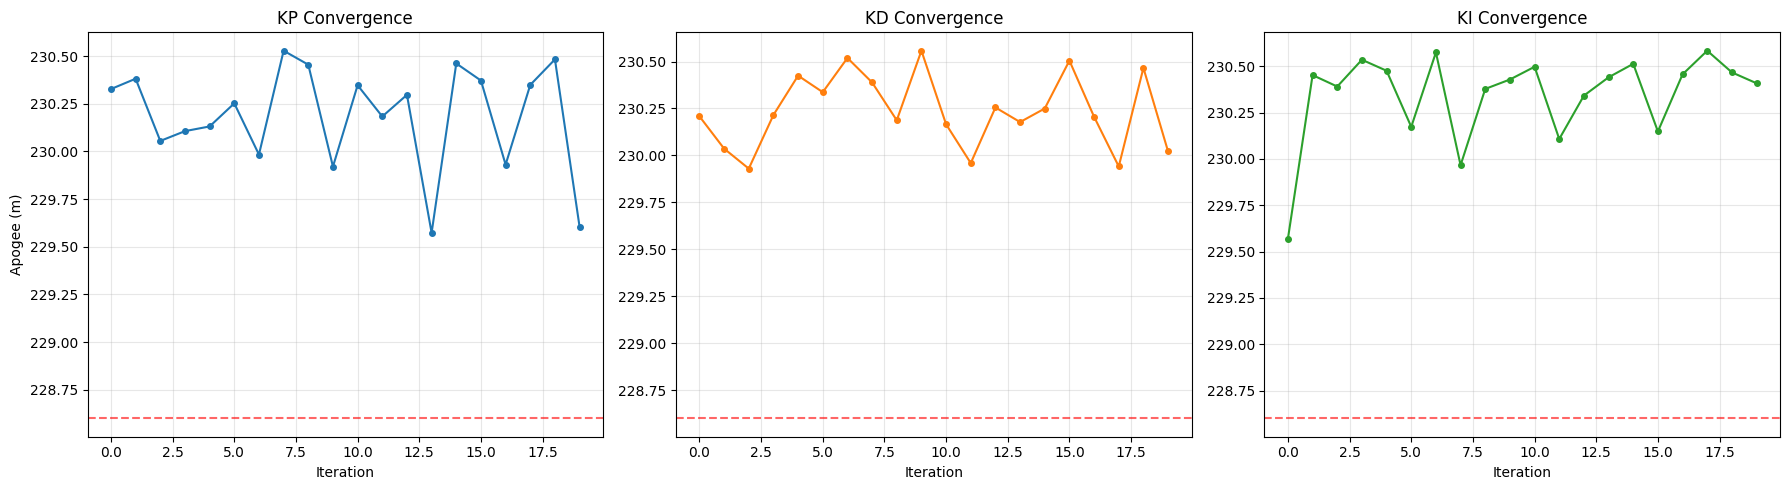

In [5]:
import matplotlib.pyplot as plt
import time
import numpy as np

def binary_search_gain(gain_name, low, high, target, constant_gains, iterations=20):
    start_time = time.time()
    history_gains = []
    history_apogees = []

    print(f"\n--- Optimizing {gain_name.upper()} ---")

    for i in range(iterations):
        mid = (low + high) / 2
        gains = constant_gains.copy()
        gains[gain_name] = mid

        # Run simulation
        run_simulation(csv_path, target_height=target, base_wind=7, ctrl_kp=gains['kp'], ctrl_kd=gains['kd'], ctrl_ki=gains['ki'])
        current_apogee = apogee

        history_gains.append(mid)
        history_apogees.append(current_apogee)

        # If apogee > target, we need MORE control/drag
        if current_apogee > target:
            low = mid
        else:
            high = mid

    duration = time.time() - start_time
    return mid, history_gains, history_apogees, duration

csv_path = "/content/ORI.csv"

# --- Execution ---
total_start = time.time()

# 1. Optimize KP
best_kp, kp_hist, kp_apo_hist, kp_time = binary_search_gain('kp', kp_low, kp_high, target, {'kp': 0, 'kd': 0, 'ki': 0})

# 2. Optimize KD (using best KP)
best_kd, kd_hist, kd_apo_hist, kd_time = binary_search_gain('kd', kd_low, kd_high, target, {'kp': best_kp, 'kd': 0, 'ki': 0})

# 3. Optimize KI (using best KP and KD)
best_ki, ki_hist, ki_apo_hist, ki_time = binary_search_gain('ki', ki_low, ki_high, target, {'kp': best_kp, 'kd': best_kd, 'ki': 0})

total_duration = time.time() - total_start

# Final validation run
run_simulation(csv_path, target_height=target, base_wind=7, ctrl_kp=best_kp, ctrl_kd=best_kd, ctrl_ki=best_ki)
final_apogee = apogee

# --- Final Print Out --- (by Gemini Flash 3.5)
print("\n" + "="*45)
print("FINAL OPTIMIZED PARAMETERS & TIMING")
print("-" * 45)
print(f"Best Kp: {best_kp:.10f} | Time: {kp_time:.4f}s")
print(f"Best Kd: {best_kd:.10f} | Time: {kd_time:.4f}s")
print(f"Best Ki: {best_ki:.10f} | Time: {ki_time:.4f}s")
print("-" * 45)
print(f"Total Optimization Time: {total_duration:.4f}s")
print(f"Final Apogee: {final_apogee:.4f} m (Target: {target}m)")
print("="*45)

# --- Plotting Convergence (Keep in optimizer) --- (by Gemini Flash 3.5)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = [('KP', kp_apo_hist), ('KD', kd_apo_hist), ('KI', ki_apo_hist)]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, (name, data) in enumerate(titles):
    axes[i].plot(data, 'o-', color=colors[i], markersize=4)
    axes[i].axhline(target, color='red', linestyle='--', alpha=0.6, label='Target')
    axes[i].set_title(f"{name} Convergence")
    axes[i].set_xlabel("Iteration")
    if i == 0: axes[i].set_ylabel("Apogee (m)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=300) # Save for the PDF script
plt.show()

# PDF Report Generator
This section was written entirely by Gemini Flash 3.5.

In [6]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import datetime
import pandas as pd
from google.colab import files
import logging

# 1. Fix the Font Error: Use fonts actually installed on Colab
# DejaVu Sans is the Linux equivalent of Helvetica/Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Ubuntu', 'sans-serif']

# Suppress font warnings from cluttering your Colab cell
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. Metadata & Filename
date_str = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
output_filename = f'PID_Optimization_Report_{datetime.datetime.now().strftime("%Y%m%d_%H%M")}.pdf'

# 3. Data Preparation (Assuming your optimizer variables exist)
kp_df = pd.DataFrame({'Iter': range(1, 21), 'Value': kp_hist, 'Apogee (m)': kp_apo_hist})
kd_df = pd.DataFrame({'Iter': range(1, 21), 'Value': kd_hist, 'Apogee (m)': kd_apo_hist})
ki_df = pd.DataFrame({'Iter': range(1, 21), 'Value': ki_hist, 'Apogee (m)': ki_apo_hist})

with PdfPages(output_filename) as pdf:

    # --- PAGE 1: TITLE PAGE (Letter Size) ---
    fig_title = plt.figure(figsize=(8.5, 11))
    fig_title.text(0.5, 0.65, "PID Control System Optimization Report",
                   ha='center', va='center', fontsize=22, fontweight='bold')
    fig_title.text(0.5, 0.58, "E-Town Rocket Bureau",
                   ha='center', va='center', fontsize=14, fontweight='bold')
    fig_title.text(0.5, 0.55, f"Generated on {date_str}",
                   ha='center', va='center', fontsize=11, fontstyle='italic')

    # BOXED CONSTANTS
    box_text = (f"FINAL OPTIMIZED CONSTANTS\n"
                f"{'-'*30}\n"
                f"Kp: {best_kp:.10f}\n"
                f"Kd: {best_kd:.10f}\n"
                f"Ki: {best_ki:.10f}\n\n"
                f"FINAL APOGEE: {final_apogee:.4f} m\n"
                f"TOTAL SIM TIME: {total_duration:.4f}s")

    fig_title.text(0.5, 0.35, box_text, ha='center', va='center', fontsize=13,
                   family='monospace', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=1.5', facecolor='#F0F5FF', edgecolor='#003264', linewidth=1.5))

    pdf.savefig(fig_title)
    plt.close(fig_title)

    # --- PAGE 2: CONVERGENCE GRAPHS (Letter Size) ---
    fig_conv = plt.figure(figsize=(8.5, 11))
    axes = fig_conv.subplots(3, 1)

    data_sets = [('KP', kp_apo_hist, 'tab:blue'),
                 ('KD', kd_apo_hist, 'tab:orange'),
                 ('KI', ki_apo_hist, 'tab:green')]

    for i, (name, data, color) in enumerate(data_sets):
        axes[i].plot(data, 'o-', color=color, markersize=4)
        axes[i].axhline(target, color='red', linestyle='--', alpha=0.6)
        axes[i].set_title(f"{name} Convergence History", fontweight='bold')
        axes[i].set_ylabel("Apogee (m)")
        axes[i].grid(True, alpha=0.2)

    plt.xlabel("Iteration")
    fig_conv.tight_layout(pad=5.0) # Using fig_conv instead of plt for safer sizing

    pdf.savefig(fig_conv)
    plt.close(fig_conv)

    # --- PAGES 3-5: DATA TABLES (Letter Size) ---
    tables = [("Kp", kp_df, kp_time), ("Kd", kd_df, kd_time), ("Ki", ki_df, ki_time)]

    for name, df, dur in tables:
        fig_tab = plt.figure(figsize=(8.5, 11))
        ax_tab = fig_tab.add_subplot(111)
        ax_tab.axis('off')

        ax_tab.set_title(f"{name} Optimization Detailed History\nSearch Duration: {dur:.4f}s",
                         pad=30, fontweight='bold', fontsize=14)

        tab = ax_tab.table(cellText=df.values.round(10),
                           colLabels=df.columns,
                           loc='center',
                           cellLoc='center')

        tab.auto_set_font_size(False)
        tab.set_fontsize(10)
        tab.scale(1.1, 1.8)

        pdf.savefig(fig_tab, bbox_inches='tight')
        plt.close(fig_tab)

# Trigger Download
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>